# INFO 264, Group Exam 2025
### Kandidate numbers: 0000, 0000, 0000, 000
---
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
### <u>Noe av det som står at vi må ha med!!!</u>
#### Important and relevant properties about the data
#### Your preprocessing steps. For example: your process of feature selection and it's results, your choices when it comes to dimension reduction (why/why not/which method/why that method) etc.
#### Based on what you have learnt from the data, why do you think that your models are best-suited for the task
#### Why the particular parameters of a model that you use, work best
#### How you control over- and underfitting
#### Your choice of evaluaon methods. Which metrics did you choose and why? Addionally, you need to give an explanation based on your intuition about why given methods perform better or worse on the given task. 
#### Finally, as a concluding comment in the Jupyter notebook, you need to write a summary of your results, and discuss consequences of such results. 
#### Please provide the list of libraries you use in the form of a `requirements.txt` in the format used by pip. 

===============================-================================

# Task 1 Sentiment Analysis
### a) Exploratory data analysis and prepocessing
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============

Gain a sufficient understanding of the data for
model development and perform data cleaning and feature engineering steps if you find it
necessary. You may make any changes to your dataset; however, you must attempt to give a
reason as to why you find a given transformation necessary. 

===============================-================================

## The data
---
When looking at the data, we found many columns that where unnecessary for our sentiment analysis. Here we list them down with a small explanation as to why they where not relevant for us, as well as those that where relevant to us.
#### <u>Non relevant data</u>
* `Hotel_Address` - Since we're not maping out which locations have more negative or positive reviews, we found this column to be irrelevant.
* `Additional_Number_of_Scoring` - The data in this column made no sense to us, and so we where unable to find a meaningfull use for it.
* `Review_Date` - Knowing the data of which the review was written is not relevant for our analysis.
* `Average_Score` - The average score the reviewer gives, is not relevant to the task at hand, because it doesn't provide any information about their review.
* `Hotel_Name` - The name of the hotel, is not data that's relevant for sentiment analysis of the reviews.
* `Reviewer_Nationality` - The nationality of the reviewer does not help us identify the sentiment of their review.
* `Review_Total_Negative_Word_Counts` - The total amount of words in a review, tells us nothing about the actual sentiment in the review.
* `Total_Number_of_Reviews` - Does not give any information about the specific review.
* `Review_Total_Positive_Word_Counts` - The total amount of words in a review, tells us nothing about the actual sentiment in the review.
* `Total_Number_of_Reviews_Reviewer_Has_Given` - The amount of reviews the author has created, does not give us any information about the sentiemnt in the review.
* `Tags` - In our case, we found that the data was not relevant for us to predict the sentiment in the review.
* `Days_since_review` - Not relevant since it doesn't give any information about the sentiment in the review.
* `lat` - Knowing the latitude does not give valuable information about the review.
* `lng` - Knowing the longitue does not give valuable information about the review.

It's important to note that all of the data we chose to not include in our analysis, could be very usefull for other analysis tasks, or even if we where to expand on our sentiment analysis, we could use some of the data to for example see if reviewers nationality, and/or the hotels location, had any effect on the sentiemnt in the reviews. 

#### <u>Relavant data</u>
* `Negative_Review`- This column holds reviews that are labeled as negative, which is exactly what we need for analysing sentiemnt and make our prediction.
* `Positive_Review` - This column holds reviews that are labeled as positive, which is exactly what we need for analysing sentiemnt and make our prediction.
* `Reviewer_Score` - Super relevant as this will be served as our `target_labels`.

After looking thoroughly through the dataset, we found that many reviews had both positive and negative labeled reviews, and that we would have to combine those reviews to properly analyse the sentiment left by the reviewer. 
 

## Preprocessing steps
---
#### <u>Har bare sett på det vi foreløpig gjør, også skrevet noen ord om det!!!</u>
* Remove unnecessary columns from the dataset
    * Takes in the whole dataset and creates a new dataset with the columns that we need.
* Removing special characters
    * Special characters don't really add any semantic meaning to the text, and they can also increase the vocabulary, because words like "room!" and "room?" will be treated as two different words. We should mention that some special characters like emojis, can carry sentiment meaning. Another example is special characters used in urls or email addresses. This can lead to some unreliable results, but these types of characters are not pressent in our dataset to the point where it would actually affect the results
* Removing digits
    * Digits in our reviews doesn't give any significant sentiment value so we discard of them.
* Removing single characters
    * Single characters can be typos, don't carry sentiment meaning, and will increase the vocabulary.
* Convert multiple spaces to one space
    * Having consistency with spacing, is important for tokenization
* Removing prefixes
    * Much like special characters, prefixes can increase the vocabulary, but it's important to remember that changing the prefix can also change the meaning of words.
* Convert to lowercase
    * Just as some of the other preprocessing steps, converting to lowercase letters will reduce the vocabulary.
* Lemmatizing words
    * Lemmatizing reduces words to their base, dictionary form. This ensures that words with the similar meaning is treated the same, and it also help the model to better understand the underlying meaning of the words. Lemming will always produce valid words, and consider context and meaning. This is opposed to Stemming, that might produce words that have no meaning, and it does not look at context. It is important to note that lemmatization comes at a cost compared to Stemming, but the increased cost is generally worth it compared to Stemming.
* Removing stopwords
    * Removing words that has no significant sentiment meaning. This also helps with reducing the vocabulary size. Important to note that the standard stopwords package contains words with sentiment meaning. This is something we were wary of, and so we could have added some of those words back.

### Preprocessing setp 1
The function, `csvConverzzion`, takes in the dataset and reads the three columns `Negative_Review`, `Positive_Review` and `Reviewer_Score`. It converts the data to a `NumPy` array to iterate over the rows. The new dataset contains only the necessary columns for our models, and is reordered for consistency.
Import libraries needed for the second preprocessing step.
The first import, `NLTK`, is a Natural Language Toolkit that has several libraries that are used for text processing. And for `NLTK` to work properly, we need to download `"stopwords"` and `"wordnet"`. We've commented-out the `NLTK` import, as well as the `"stopwords"` and `"wordnet"` downloads, because these downloads are downloaded to the system, not the project, which means that you only need to download them once. We could remove the code, but chose to keep it with regards to the exam.
* The `"stopwords"` download is a standardized list of words that generally don't carry sentiment meaning, though important to note that some stopwords can have sentiment meaning or change the sentiment of a sentence if removed. This is something we have to take into consideration when sentiment analysis is the goal of our assignment. This collection of words is then used by the `stopwords` library in `corpus`, to remove words from our data, that's not contributing to the meaning or sentiment of the sentences we're analyzing. Also important to note the language of the sentences we're analyzing, and adjust accordingly, in our case, english.

* `"wordnet"` downloads a dictionary dataset that's structured in a way that captures semantic relationship between words. `WordNetLemmatizer` uses this dataset when lemmatizing our text.


In [9]:
import pandas as pd
def csvConverzzion(_Path, _sPathNew, _useCols = ["Negative_Review", "Positive_Review", "Reviewer_Score"], _sEncoding = "utf-8"):
    _dataset = pd.read_csv(_Path, usecols = _useCols)
    _mergedReviews = []
    for i in _dataset.to_numpy():
        _mergedReviews.append([ i[2], i[0], i[1] ])
    pd.DataFrame(_mergedReviews, columns = ["Reviewer_Score", "Negative_Review", "Positive_Review"]).to_csv(_sPathNew, encoding = _sEncoding)

csvConverzzion('./data/Hotel_Reviews.csv', "./data/Hotel_Reviews_Reduced.csv")

In [4]:
import nltk # Needed to download 'stopwords', 'wordnet' and 'punkt_tab'.
# nltk.download('stopwords') # Needed for downloading 'stopwords' one time.
# nltk.download('wordnet') # Needed for downloading 'wordnet' one time.
# nltk.download("punkt_tab") # Needed for downloading 'punkt_tab' one time.
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
import re
from nltk.stem import WordNetLemmatizer

lemma = WordNetLemmatizer()

In [5]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Fjernet Lowercase converting herfra fordi gensim simple_preprocess gjør det by default.
# Fjernet model spesifikke funksjoner ettersom vi kaller de enkle funksjonene når vi trenger dem.
# Fjernet target_score_to_n
# ===================================================================

# The clean_sentences function has been heavily inspired by "https://stackabuse.com/text-classification-with-python-and-scikit-learn/" text processing.
 
# An indenpendent function that cleans the sentences up.
# Returns a list of the cleansed sentences, and the data variable which was used.
def clean_sentences(data):
    all_text = []
    for sen in range(0, len(data)):
        # Remove all the special characters
        text = re.sub(r'\W', ' ', str(data.iloc[sen]))
        # Remove all numbers
        text = re.sub(r'\d', ' ', text)
        # remove all single characters
        text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
        # Remove single characters from the start
        text = re.sub(r'\^[a-zA-Z]\s+', ' ', text) 
        # Substituting multiple spaces with single space
        text = re.sub(r'\s+', ' ', text, flags=re.I)
        # Removing prefixed 'b'
        text = re.sub(r'^b\s+', '', text)
        # Lemmatization
        text = text.split()

        # Converting to Lowercase
        for c in range(len(text)):
            text[c] = text[c].lower()

        text = [lemma.lemmatize(word) for word in text if word not in (stop_words)]
        text = ' '.join(text)

        all_text.append(text)
    return all_text

def combine_reviews(data):
    X_1, X_2 = clean_sentences(data["Negative_Review"]), clean_sentences(data["Positive_Review"])
    X = []
    for n in range(len(X_1)):
        if X_1[n] and X_2[n] is None:
            pass
        elif X_1[n] == 'negative' or X_1[n] is None:
            X.append(X_2[n])
        elif X_2[n] == 'positive' or X_2[n] is None:
            X.append(X_1[n])
        else:
            X.append(X_1[n] + " " + X_2[n])
    return pd.array(X)

# Small change to threshhold to balance the data
def target_score_to_expression(data):
    y_n = data["Reviewer_Score"].values
    y = []
    for value in y_n:
        if value < 6:
            y.append("negative")
        elif value < 8:
            y.append("neutral")
        else:
            y.append("positive")
        
    return pd.array(y, dtype='object')

### Model preprocessing steps
All of our models goes through this step, but the functions used is dependent on the model.

1. <u> All models:</u>
    * Every single model we use start på using `combine_reviews` to combine the reviews from the dataset.
    * While `combine_reviews` is combining the reviews, it also calls `clean_sentences` on both columns, on each row, to remove special characters, single characters, replaces multiple spaces with one space, removes prefixes, converts to lowercase, lemmatizes the words and removes stopwords. All this is done to get more consistent text, as well as remove unnecessary words that only serve to increase the vocabulary.
    * For evalutaing our models we decided that using ``accuracy`` would be the best metric to train our models. Since it's creating a recognizable pattern for negative, neurtal and positive.

2. <u>The LSTM model uses the following:</u>
    * The `target_score_to_n` function is used to convert the score associated with each review, into one-hot encoded labels `[0, 1, 0]`. This is done to represent the target classes `negative`, `positive` and `neutral`. By converting the classes to numerical arrays, we make them suitable for training. One-hot encoding labels are also needed when using loss functions like `categorical_crossentropy`.
    * This is all done to standardize the text and reduce noice, which helps the LSTM model focus on meaningful patterns

3. <u>The KNN model uses the following:</u>
    * We start similarly to LSTM and convert the score into labels `[0, 1, 0]` and make the target classes into `negative`, `positive` and `neutral`, but before we seperate the training and test data we convert the one-hot encoded labels to either `0, 1 or 2`. This is done to fit better into our KNN model.

4. <u>The NLP model uses the following:</u>
    * For our target data we use `target_score_to_expression` which takes the `reviewer_score` from the dataset to represent them with `negative`, `positive` and `neutral`. Here we don't use one-hot encoded labels since it's more readable than, `[0, 1, 0]`. The target value isn't really that relevant when training our model so that's why we chose a more readable approach.
    * In addition we use a `CountVectorizer` to turn our `review_strings` to a fitted `bag_of_words` for our model which you will see below.

5. <u>The CNN model uses the following:</u>
    * Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt.
    * Ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in. 
    * Voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

### b) Models
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============

Build four (4) machine learning models for labelling sentiment behind hotel reviews.
One of the models needs to be a neural network (e.g. LSTM). You are welcome to train
models that are not covered in the course. Evaluate the performance of the built models
using the appropriate evaluation metrics 

===============================-================================

##### When building our LSTM model and how to preprocess we used this repository as a guideline to create a suitable model for our task: "https://github.com/sergiovirahonda/TweetsSentimentAnalysis/blob/main/TweetsSentimentPredictions.ipynb"

In [10]:
train = pd.read_csv('./data/Hotel_Reviews_Reduced.csv')
print(len(train))

515738


#### Model Imports
All the imports needed for our models

In [8]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Fjernet duplikater og ubrukte funksjoner

# ===================================================================

# Importing the necessary libraries for the LSTM model.
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import tensorflow as tf
import warnings
from gensim.models import Word2Vec;
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras import layers, datasets, models, callbacks
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from typing import Iterable
warnings.filterwarnings('ignore')

Combine the negative and positive reivew column on each row. During the combining process, the words are also cleaned by removing special characters, single characters, multiple spaces, prefixes and at the end it also lemmatizes the words. Since we are going to process y some more and the NLP model will not need it, we save y_nlp as it's own variable.

In [12]:
X = combine_reviews(train)
y = target_score_to_expression(train)
y_nlp = target_score_to_expression(train)

One-hot encode the labels

In [13]:
labels = np.array(y)
y = []
for i in range(len(labels)):
    if labels[i] == 'neutral':
        y.append(0)
    if labels[i] == 'negative':
        y.append(1)
    if labels[i] == 'positive':
        y.append(2)
y = np.array(y)
labels = tf.keras.utils.to_categorical(y, num_classes=3)

In [ ]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Med fullført preprocessing så har vi følgende mengde ord:
# 10331478 ord
# 73439 unike ord
# 18941 ord forekommer 5 ganger eller mer
# 95% av reviews er 55 ord eller færre 
# ===================================================================

#### LSTM Model

Since we had to use a neural network we chose the recomended one which was LSTM. We have tried and failed many times with this model, but with a little guideline we have created a very optimal solution to the task. As we change weights based on accuracy it will most likely be the best model. In addition it is quite more powerful than some of the other models we have used.

For faster training, we have opted to use tensorflow with a GPU.

In [8]:
max_words = 5000
max_len = 55

# Tokenize and pad the data.
tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
reviews = pad_sequences(sequences, maxlen = max_len)

X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = train_test_split(reviews, labels, random_state = 0)

#### Training the LSTM model

We add an ``Embedding`` with the ``max_words`` since this is how many features we have in our tokeinzer. Next we add a ``Masking`` with the ``mask_value`` set to 0 to skip any timestep equal to the ``mask_value``. Then a layer with 20 units of ``LSTM`` with a ``dropout`` of 0.3 to prevent overfitting. We use the ``activation="relu"`` since this activation is efficient and works nicely with sentiment analysis. In our last layer we create an output layer with 3 ``Dense`` units with an ``activation="softmax"`` since we mostly want a prediction percentage than a float value between for example -200 and 200. In our compiler we use an ``optimizer="rmsprop"`` which works quite nicely with our task, in addition we look at out ``loss`` based on the `categorical_crossentropy` which is the best loss method for our task with 3 outputs with ``one-hot encoders``. As we said earlier we use the metric `accuracy` to train our model to be the best. In addition we add a `ModelCheckpoint` to save the best model we got under our training. We also have an`` early_stopping`` method that stops the epochs if ``val_loss`` does not improve over 5 epochs.

In [9]:
with tf.device('/GPU:0'):
    model = Sequential()
    model.add(layers.Embedding(max_words, 20))
    model.add(layers.Masking(mask_value=0))
    model.add(layers.LSTM(20,dropout=0.3, activation='relu'))
    model.add(layers.Dense(3,activation='softmax'))
    model.compile(optimizer='rmsprop',loss='categorical_crossentropy', metrics=['accuracy'])

    early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

    # Implementing model checkpoins to save the best metric and do not lose it on training.
    checkpoint = ModelCheckpoint("best_model.keras", monitor='val_accuracy', verbose=1,save_best_only=True, mode='auto',save_weights_only=False)
    history = model.fit(X_train_LSTM, y_train_LSTM, epochs=50, batch_size=256,validation_data=(X_test_LSTM, y_test_LSTM),callbacks=[checkpoint, early_stopping])

Epoch 1/50
1510/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6852 - loss: 0.7308
Epoch 1: val_accuracy improved from -inf to 0.72842, saving model to best_model.keras
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.6852 - loss: 0.7307 - val_accuracy: 0.7284 - val_loss: 0.6066
Epoch 2/50
1510/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7334 - loss: 0.6022
Epoch 2: val_accuracy improved from 0.72842 to 0.73468, saving model to best_model.keras
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.7334 - loss: 0.6022 - val_accuracy: 0.7347 - val_loss: 0.5907
Epoch 3/50
1510/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7392 - loss: 0.5860
Epoch 3: val_accuracy improved from 0.73468 to 0.74008, saving model to best_model.keras
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.7392 - loss: 0.5860 - val_accuracy: 0.7401 - val_loss: 0.5773
Epoch 4/50
1509/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7417 - loss: 0.5805
Epoch 4: val_accu

In [10]:
# Load the best model obtained during training
best_model_LSTM = keras.models.load_model("best_model.keras")

In [11]:
# Evaluate the model and print out the accuracy.
test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)
print('Model accuracy: ',test_acc_LSTM)

4030/4030 - 13s - 3ms/step - accuracy: 0.7475 - loss: 0.5658
Model accuracy:  0.7474774122238159


4030/4030 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step


<Axes: >

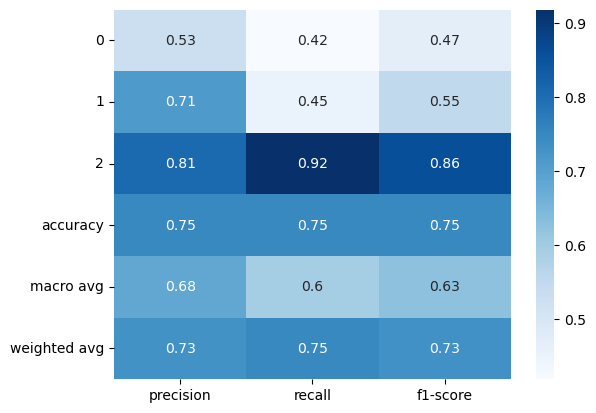

In [12]:
# Create a classification report and use seaborn to show it.
predictions = best_model_LSTM.predict(X_test_LSTM)
clf_report_LSTM = classification_report(np.argmax(y_test_LSTM, axis=1), np.argmax(predictions, axis=1), output_dict=True)


sns.heatmap(pd.DataFrame(clf_report_LSTM).iloc[:-1, :].T, annot=True, cmap="Blues")

<Axes: >

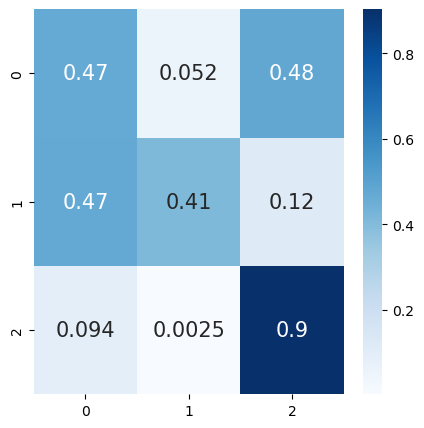

In [ ]:
# Create a confusion matrix.
matrix_lstm = confusion_matrix(y_test_LSTM.argmax(axis=1), np.around(predictions, decimals=0).argmax(axis=1))

conf_matrix = pd.DataFrame(matrix_lstm, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis=1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix, annot=True, annot_kws={"size": 15}, cmap="Blues")

4030/4030 - 11s - 3ms/step - accuracy: 0.7475 - loss: 0.5658


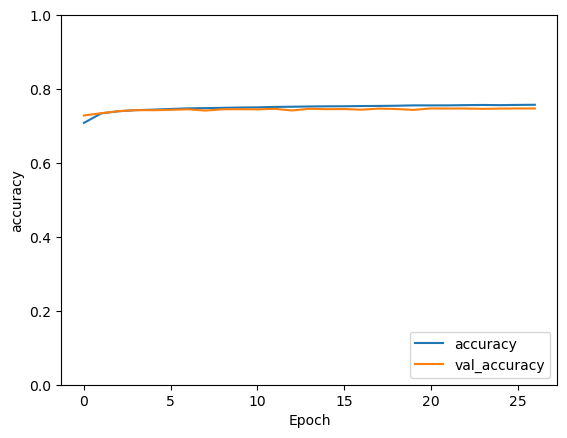

In [ ]:
# Create a graph to check overfitting and underfitting.
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)

#### KNN Model

We started with a KNN model that used the columns ``Review_Total_Negative_Word_Counts``, ``Review_Total_Positive_Word_Counts`` and ``Average_Score``. This got a result that only predicted based on how many positive or negative words there were, not the review text as the task asked for. In addition we also wanted to use the same data for all of our models so we swtiched our approach on KNN. After some testing we found that using ``TfidfVectorizer`` (Term Frequency-Inverse Document Frequency) was the right way to go:
* Term Frequency is how often a word appears in a text.
* Invers Document Frequency reduces the weight of common words across multiple documents while increasing the weight of rare words.
We used this to categorize the words into different levels of importance. We use the min_df = 5 to say that a word needs to be found at least 5 times to count.  
After some testing we used ``KNearestNeigbour`` with 13 neighbours and 20% of the data to train and the rest of the set to predict the result.

We evaluate the data with both a classification report and confusion matrix. We also check with a graph to calculate overfitting and/or underfitting.

Source: https://www.geeksforgeeks.org/understanding-tf-idf-term-frequency-inverse-document-frequency/   


### Hvorfor?


Mangler forklaringer på noe av koden
Mangler forklaring på hva output forteller oss


Convert the one-hot encoded labels to a 1D array.

In [14]:
labels_convert_KNN = np.argmax(labels, axis=1)

Vectorizing the reviews, we use the same features as our tokenizer in the LSTM model.

In [ ]:
vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 1), min_df = 5)
vectorize_reviews = vectorizer.fit_transform(X) 

Split the data into training and testing sets. Testing on 20% of the data with a random state at 42 because that's the answer to life, the universe, and everything

In [ ]:
X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(vectorize_reviews, labels_convert_KNN, test_size = 0.2, random_state = 42)

After a lot of time we found that KNN is a higly inneficient method compared to the other models. More details on this in the conclution.

In [ ]:
k = 13
knn_model = KNeighborsClassifier(n_neighbors = k)
knn_model.fit(X_train_KNN, y_train_KNN)

Creating a classification report
Create a classification report and use seaborn to show it.

In [ ]:

y_pred_knn = knn_model.predict(X_test_KNN)
clf_report_KNN = classification_report(y_pred_knn, y_test_KNN, output_dict=True)

sns.heatmap(pd.DataFrame(clf_report_KNN).iloc[:-1, :].T, annot=True, cmap="Blues")

Creating a confusion matrix

In [ ]:
matrix_knn = sklearn.metrics.confusion_matrix(y_pred_knn, y_test_KNN)

conf_matrix = pd.DataFrame(matrix_knn, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis=1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix, annot=True, annot_kws={"size": 15}, cmap="Blues")

Creating a graph to check over/under-fitting

In [ ]:
# Calculate overfitting for the model
train_accuracy = accuracy_score(y_train_KNN, y_pred_knn)
test_accuracy = accuracy_score(y_test_KNN, y_pred_knn)
overfitting = train_accuracy - test_accuracy


plt.plot(knn_model.history['accuracy'], label='accuracy')
plt.plot(knn_model.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

print(f"Overfitting: {overfitting}")

k = 3
[[ 19  13  18]
 [  7   9   2]
 [220  80 632]]
train_accuracy: 0.688
test_accuract: 0.66
overfitting: 0.027999999999999914
--------------------------------------------------


## TRENGS Å KJØRE PÅ NYTT, FEIL K


This output shows that the model is heavily leaning towards a positive result, where almost all of the entries is registerd as positive. The model also gives many false positives that should be neutral or false. The training set has a fairly high accuracy with ~69% correct and the actual testing set has an accuarcy of 66% which is also fairly high. The model also has low overfitting. 



#### NLP Model

We use this model since Natural Language Processing models are widely used when tackling sentiments analysis.

As per "Zubair Ashfaque" from "https://medium.com/@zubairashfaque/sentiment-analysis-with-naive-bayes-algorithm-a31021764fb4":  

__Sentiment Analysis with the Naive Bayes algorithm is a powerful approach, using probability and linguistic analysis to categorize text sentiments as positive, negative, or neutral. By preprocessing text, calculating log priors, and deriving log-likelihoods, this method quantifies sentiment, guiding accurate classification.__

<br>

After doing some testing with both `MultinomialNB` and `BernoulliNB` we found that `MultinomialNB` had the best accuracy with our data which is our score metric to our models. In addition we also experimented with `CountVectorizer` and `TfdifVectorizer` and found that `CountVectorizer` was a better fit with the data to get the most accurate model. Even though `TfdifVectorizer` was better overall at finding positive reviews.

In [31]:
# Since the dataset is so huge, we use the 5000 of the most common words, and we want to use the words that contains in at least 5 reviews. In addition we use words
# that are in a maximum of 60% of our reviews to remove non meaningful words.
cv = CountVectorizer(max_features=5000, min_df=5, max_df=0.6)
X_nlp = cv.fit_transform(X)

X_train_NLP, X_test_NLP, y_train_NLP, y_test_NLP = train_test_split(X_nlp, y_nlp, test_size=0.2, random_state=42)

In [32]:
# Train the model
print("MultinomialNB:")
nlp_model = MultinomialNB()
nlp_model.fit(X_train_NLP, y_train_NLP)

MultinomialNB:


MultinomialNB()

{'negative': {'precision': 0.5086644327429392, 'recall': 0.49691358024691357, 'f1-score': 0.5027203482045702, 'support': 10692.0}, 'neutral': {'precision': 0.4675270607826811, 'recall': 0.39677305382169353, 'f1-score': 0.4292539975791553, 'support': 25473.0}, 'positive': {'precision': 0.8062038404726736, 'recall': 0.8555752952241613, 'f1-score': 0.8301561549381464, 'support': 66983.0}, 'accuracy': 0.7050936518400744, 'macro avg': {'precision': 0.5941317779994312, 'recall': 0.5830873097642562, 'f1-score': 0.5873768335739573, 'support': 103148.0}, 'weighted avg': {'precision': 0.6917236279965276, 'recall': 0.7050936518400744, 'f1-score': 0.6972100551591786, 'support': 103148.0}}


<Axes: >

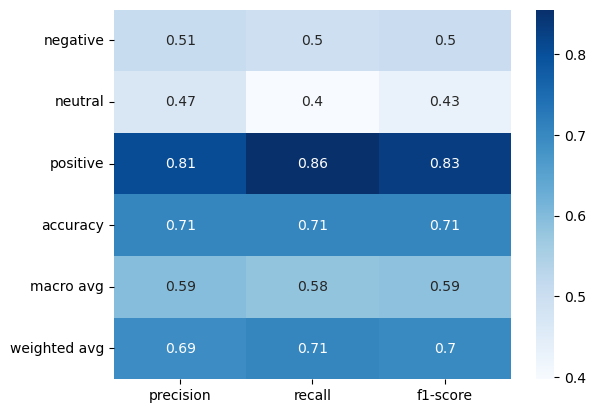

In [33]:
# Creating a classification report
y_pred_nlp = nlp_model.predict(X_test_NLP)
clf_report_NLP = classification_report(y_test_NLP, y_pred_nlp, output_dict=True)
print(clf_report_NLP)

sns.heatmap(pd.DataFrame(clf_report_NLP).iloc[:-1, :].T, annot=True, cmap="Blues")

<Axes: >

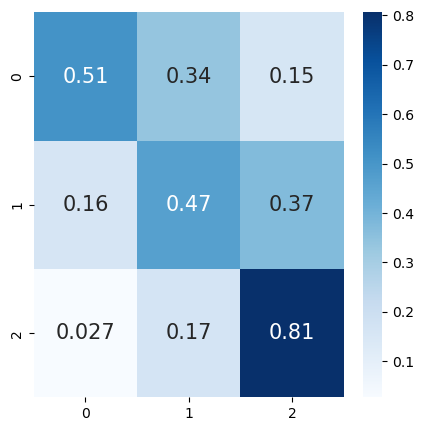

In [35]:
# Creating a confusion matrix
matrix_nlp = sklearn.metrics.confusion_matrix(y_pred_nlp, y_test_NLP)

conf_matrix = pd.DataFrame(matrix_nlp, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis=1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix, annot=True, annot_kws={"size": 15}, cmap="Blues")

In [ ]:
# Calculate overfitting for the model
train_accuracy = accuracy_score(y_train_NLP, y_pred_nlp)
test_accuracy = accuracy_score(y_test_NLP, y_pred_nlp)
overfitting = train_accuracy - test_accuracy

print(f"Overfitting: {overfitting}")

TypeError: 'MultinomialNB' object is not subscriptable

#### CNN Model

I wanted to use a convolutional network for the statistical analysis of the reviews


### FUNCTIONS FOR DATA PREPROCESSING

What follows is all the functions for loading, preprocessing, and structuring the data.

The dataframeConverzzion function is used to load the parts of the data that are useful for this. It loads the score of the review, and it merges the positive and negative text into one review text.

What we want to predict the sentiment of the review, if the review is positive, neutral, or negative. We want to predict sentiment from only the review text, so we take the two possible texts and simply merge them into one.

## PREPARATION

The review target value is prepared as follows: The review score value is rounded and a category id is assigned to the review based on its score: negative: 0 through 6, neutral: 7 through 8, positive: 9 through 10. Then the output category ids are one hot encoded for each review.

The datasetPreparation function handles the lemmatization / stemmatization of the words, and the removal of stop words.

Stop words are words that don't carry much referential meaning, classes of words like pronouns, subjunctions, prepositions, etc. These words are arguably very important for language analysis, since they define the structure of the sentence and the relations between constructions in the sentence that carry reference to the real world, things like noun groups, verb groups, etc. Still, we decide to exclude the structural words since it would take more complex language analysis to include sentence structure as part of the analysis, and we believe that we can get good enough statistical analysis from just the referential words. The assumption is that if the reviewer wants to talk about what was bad about the hotel, they are likely to use some adjectives over others. We assume it's a lot more likely that a reviewer would use a word like "uncomfortable", "dirty", or "terrible", when they are giving a bad review, and words like "comfortable", "clean", or "amazing" when they are giving a good review. With this assumption, the actual larger structure of the sentence doesn't mean as much, and thus structural words aren't needed.
Though, on words like "amazing": it is the case that people often use the same words to describe both good and bad. In these cases, we assume that words like these wont be picked up as particularily significant by the network, and thus wouldn't impact the analysis.

We also lemmatize the words in the text, which means that we take words that derive from the same core and reduce them to the same word representing the core. The words "connect", "connection", "connecting", etc, all derive from "connect" and will all be replaced by that word. The argument for lemmatizing is similar: we assume that different forms of the same word have similar enough meaning and usage that we can get a good enough statistical analysis by just treating them as the same word. This is the same reasoning as the assumption made earlier about that word reference is enough for language analysis, and that structural context isn't necessary.


## VECTORIZATION

The words are then converted to vectors to reduce processing time. The function datasetVectorization() is used for this. The word vectors cannot have only one channel with the word encoded into a number as an id representing it because of how gradient descent works. The neural network uses gradient descent, which assumes that the function is continuous, that the output interpolates smoothly between two input vectors as the values of one vector interpolate into the other vector. This excludes id encoding because words with ids close to each other are not at all guarranteed to have similar meanings, and for one dimension, it is basically impossible as the set of words grows, given that words have many "axies" of meaning.

One hot encoding won't work either, one: because it would require a number of channels for the word vector equal to the number of words; this excludes this approach because of how much memory and processing time it would require, and B: because the input vectors would be far far to sparse with meaning to draw anything out of; which is why this encoding style isn't used for these kinds of networks. //// SOURCE

One solution to this is turning the words into vectors using a system that can somehow figure out commonalities between the words or how they relate to each other or any kind of pattern, and figures out a number of "axies" of meaning for each word. One such system is implemented by the Word2Vec class of gensim. It takes a model for vectorization and trains itself according to the model and a set of words provided. After this, a word can be inputted to the Word2Vec instance, and it will return an array of values. This array is the vector we use to represent the word, which we feed into the network. //// SOURCE

After this step, the array structure should look something like this: 
<code> datasetX: [ [ [ float32, ... (k) ], ... (m) ] ... (n) ]; </code>,
where <code> n </code> is the number of reviews, <code> m </code> is the length of the review, and <code> k </code> is the dimension of the word vector.

We see that the reviews may have varying numbers of words, meaning the the arrays of word vectors would vary in length. To feed the array into the network, it needs to be converted to a tensor. The problem is that tensors are required to be like transcendentally rectangular, and the arrays of words varying in length is not comaptible with that. I did assume that a cnn with a convolutional layer as the input would be able to account for this, since the layer just strides from one end of the texture to the other, but apparently tensorflow doesn't vibe with that. Either that or I'm dumb. Honestly, I can swear that it is very possible to make a convolutional algorithm, even parallelized, that can take varying input length, but this course isn't about us actually making anything, so problem it is.

To solve this, I just padd the reviews to the length of the longest review, with word vectors where all the numbers are 0. This should be fine, since the vectorizer makes word vectors with values from -1 to 1, so 0 would be neutral; that the word vector has no meaning on that axis.

The number of fragment channels was chosen based on testing. A larger number of channels consistently gave better results, and I theorize that this trend would probably continue up until a number of channels that is some larger fraction of the total number of unique words in all the reviews, but more channels increases memory usage and training time, so we never really got to test this theory on the entire dataset. I theorize assume that as the number of channels reaches past like a quarter of all the unique words, the network would start to perform worse, since there would be too many channels and not enough words to generate meaning, leading to a similar situation as the one hot encoding, and when it equals to the number of unique words, it would be basically equivalent to a one hot encoding, and as it goes above, it would just be like a padded out one hot encoding. Again, we didn't get to actually test the one hot encoding, and we didn't get to test larger numbers of channels, so I can't really show data to attest to this theory.


## DEFINING MODEL

The model uses a convolutional layer as input. The size and stride length of the filters was chosen based on testing. We found that these values were the ones that gve best results. //// DOUBLE CHECK THIS: // A filter too small performed not so good. I theorize that this is because words in a sentence relate to each other across larger distances in a stream of speech or text, so a wider filter would do better. What I also saw was that when the filter was too large, it performed worse. I theorize that this is because words that are far appart don't mean much for each other, not as much as words that are close to each other, so they would mostly just be noise in the filter.

The 1d convolutional layer gives a 2d output because there is a neuron for each channel of the fragments in the texture, so there is 1 dimension from the fragment channels and 1 dimension from the convolutional layer dimensionality. I use a flatten layer after the convolutional layer to turn the 2d output of the layer into a 1d output. All the outputs are kept in tact, just sequenced into a line.

I use a couple more layers after the convolutional layer to properly interpret the output of it and narrow it down to the three categories: positive, neutral, negative. I use some dropout layers in between the other layers because by disregarding some of the inputs from one layer to the next, it makes the network more resilient, because if a layer can't rely on the value of a neuron to always be usable, it has to find other patterns to reinforce, which makes the network spread the pattern recognition wider across the neurons in the layer.
//// SOURCE: https://medium.com/@utsavraj.ptn04/dropping-the-knowledge-bomb-understanding-dropout-layers-in-deep-learning-0612f517269d

The model uses early stopping which it does in relation to loss. This is because if the model starts to perform worse with training, it is important to stop it when it is close to its peak. I have given the model a higher patience value, this is because I wanted it to try a little harder before giving up, because the graphs that I saw of accuracy tended to have some ups and downs, so the model should be a little more cool and levelheaded and hold the stocks a little longer. Also it was a bit sad to see the model give up after 10 out of 50 epochs.


## RESULTS



In [ ]:
#############
# DATAFRAME CONVERZZION

def dataframeConverzzion( _dataset ):
    _mergedReviews = [];
    for i in _dataset.to_numpy():
        _mergedReviews.append({ "score": i[2], "review": i[0] + " " + i[1] });
    return _mergedReviews;


In [ ]:
#############
# DATASET EXTRAXXION

def entryExtraxxion( _entry, _col ):
    _entryExtracc = [];
    if( isinstance(_entry[_col], Iterable) ):
        for _word in _entry[_col]:
            _entryExtracc.append(_word);
        return _entryExtracc;
    else:
        return _entry[_col];

def datasetExtraxxion( _dataset, _col ):
    _datasetExtracc = [];
    for _entry in _dataset:
        _entryExtracc = entryExtraxxion(_entry, _col);
        _datasetExtracc.append(_entryExtracc);
    return _datasetExtracc;


In [ ]:
#############
# DATASET PREPARATION

nonWords = nltk.corpus.stopwords.words("english");

stemma = nltk.PorterStemmer();

def stringClean( _string ):
    _string = _string.lower();
    _string = re.sub(r"\d+", "", _string);
    _string = re.sub(r"[^\w\s]", "", _string);
    return _string;

def lemmaBalls( _string ):
    _text = nltk.word_tokenize(_string);
    _textLemma = [];
    for _word in _text:
        _wordLemma = lemma.lemmatize(_word);
        if not (_wordLemma in nonWords):
            _textLemma.append(_wordLemma);
    return _textLemma;

def stemmaBalls( _string ):
    _text = nltk.word_tokenize(_string);
    _textStemma = [];
    for _word in _text:
        _wordStemma = stemma.stem(_word);
        if not (_wordStemma in nonWords):
            _textStemma.append(_wordStemma);
    return _textStemma;

def datasetPreparation( _dataset, _mode =  "lemma" ):
    _datasetPrepare = [];
    _entryLongest = 0;
    if( _mode == "lemma" ):
        for _review in _dataset:
            _reviewPrepare = { "score": _review["score"], "review": lemmaBalls(stringClean(_review["review"])) };
            _datasetPrepare.append(_reviewPrepare);
            if( len(_reviewPrepare["review"]) > _entryLongest ):
                _entryLongest = len(_reviewPrepare["review"]);
    elif( _mode == "stemma" ):
        for _review in _dataset:
            _reviewPrepare = { "score": _review["score"], "review": stemmaBalls(stringClean(_review["review"])) };
            _datasetPrepare.append(_reviewPrepare);
            if( len(_reviewPrepare["review"]) > _entryLongest ):
                _entryLongest = len(_reviewPrepare["review"]);
    else:
        raise ValueError("provided preparation mode does not exist");

    return _datasetPrepare, _entryLongest;


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ivans\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ivans\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ivans\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
#############
# SCORE: (abstract python decimal number) TO LABEL CONVERZZION

const_labelMap = {
    "negative": 0,
    "neutral": 1,
    "positive": 2,
};

const_LabelUnmap = {
    0: "negative",
    1: "neutral",
    2: "positive",
};

const_scoreMap = {
     0: 0,
     1: 0,
     2: 0,
     3: 0,
     4: 0,
     5: 0,
     6: 0,
     7: 1,
     8: 1,
     9: 2,
    10: 2,
};

def entryLabelConverzzion( _score ):
    return const_scoreMap[round(_score)];

def datasetLabelConverzzion( _dataset ):
    _datasetLabel = [];
    for _entry in _dataset:
        _datasetLabel.append( entryLabelConverzzion( _entry ) );
    return _datasetLabel;


In [ ]:
#############
# DATASET VECTORIZATION

def entryVectorization( _entry, _model, _fragmentChannels, _resolutionLargest = -1 ):
    _entryLength = len( _entry );
    if( _resolutionLargest >= 0 ):
        _currentLength = _resolutionLargest;
        if( _entryLength > _resolutionLargest ):
            _entryLength = _resolutionLargest
    else:
        _currentLength = _entryLength;
    
    _entryVecc = np.zeros( (_currentLength, _fragmentChannels), dtype = float );

    for _i in range( _entryLength ):
        _word = _entry[_i];
        if( _word in _model.wv ):
            _wordVecc = _model.wv[_word];
            for _j in range( _fragmentChannels ):
                _entryVecc[_i][_j] = _wordVecc[_j];
    
    return _entryVecc;

def datasetVectorization( _datasetX, _model, _fragmentChannels, _resolutionLargest = -1 ):
    _datasetVecc = [];
    for _review in _datasetX:
        _reviewVecc = entryVectorization(_review, _model, _fragmentChannels, _resolutionLargest);
        _datasetVecc.append(_reviewVecc);
    return _datasetVecc;


In [ ]:
#############
# DATASET TENSOR CONVERZZION

def datasetTensorConverzzion( _datasetX, ):
    _datasetTense = [];
    for _reviewTense in _datasetX:
        _reviewTense = tf.convert_to_tensor(_reviewTense);
        _datasetTense.append(_reviewTense);
    return _datasetTense;

def datasetCategoricalConverzzion( _datasetY ):
    _datasetCat = tf.keras.utils.to_categorical( _datasetY );
    return _datasetCat;


In [12]:
#############
# DOING THE DATA UNTIL ITS WELL DONE

""" does the data very thoroughly, really properly does it

does data to following format:

n = number of reviews;
m = number of words in review;
k = number of channels per vectorized word

dataset: [ entry, ... (n) ];
entry: { "review": texture, "score": socre };
texture: [ fragment, ... (m) ];
fragment: [ colourChannel, ... (k) ];
colourChannel: float32;
score: [ boolean, boolean, boolean ];

dataset: [ [ [ [ float32, ... (k) ], ... (m) ], [ boolean, boolean, boolean ] ] ... (n) ];

datasetX: [ texture ... (n) ];
datasetY: [ score ... (n) ];

"""
def doData( _path, _preparationMode = "lemma", _fragmentChannels = 100, _vectorizationMode = "skip", _padVectors = False ):
    # i offer my apologies and regrets for doing this functionally instead of operationally
    # this basically takes twice the memory it needs to take because of it
    # well its ok (ish)
    print("    # started preparation");
    _dataset = pd.read_csv( _path, usecols = ["Negative_Review", "Positive_Review", "Reviewer_Score"] );
    _dataset = dataframeConverzzion( _dataset );
    _dataset, _resolutionLargest = datasetPreparation( _dataset, _mode = _preparationMode );
    _datasetX = datasetExtraxxion(_dataset, "review");
    _datasetY = datasetExtraxxion(_dataset, "score");
    _dataset = None;
    print("    # finished preparation");
    
    if( not _padVectors ):
        _resolutionLargest = -1;

    print("    # started vectorization");
    _model = None;
    if( _vectorizationMode == "skip" ):
        # Create Skip Gram model
        _model = Word2Vec( _datasetX, min_count = 1, vector_size = _fragmentChannels, window = 5, sg = 1 );
    elif( _vectorizationMode == "bow" ):
        # Create CBOW model
        _model = Word2Vec( _datasetX, min_count = 1, vector_size = _fragmentChannels, window = 5 );
    else:
        raise ValueError( "provided vectorization mode does not exist" );
    print("    # finished vectorization");

    _datasetX = datasetVectorization( _datasetX, _model, _fragmentChannels, _resolutionLargest = _resolutionLargest );
    
    _datasetY = datasetLabelConverzzion( _datasetY )
    _datasetY = datasetCategoricalConverzzion( _datasetY );

    print("    # dataset size:", len(_datasetX), len(_datasetY));
    
    print("    # started splitting");
    _datasetTrainX, _datasetTestX, _datasetTrainY, _datasetTestY = train_test_split( _datasetX, _datasetY, test_size = 0.20, random_state = 1 );
    print("    # started splitting");

    print("    # outputting dataset");
    return \
        np.array(_datasetTrainX), \
        np.array(_datasetTestX), \
        _datasetTrainY, \
        _datasetTestY, \
        _resolutionLargest;
    

In [ ]:
#############
# NETWORK: DEFINING /// COMPILING /// TRAINING

def makeModel( _datasetTrainX, _datasetTestX, _datasetTrainY, _datasetTestY, _resolution, _channels ):
    print("    # started model");
    with tf.device("/GPU:0"):
        _model = models.Sequential();
        _model.add( layers.Input( shape = ( _resolution, _channels ), dtype = "float32" ) );
        _model.add( layers.Conv1D( 32, 4, activation = "relu", strides = 1, data_format = "channels_last" ) );
        _model.add( layers.Dropout( 0.2 ) );
        _model.add( layers.BatchNormalization() );
        _model.add( layers.Dense( 192, activation = "relu" ) );
        _model.add( layers.BatchNormalization() );
        _model.add( layers.Flatten() );
        _model.add( layers.Dropout( 0.3 ) );
        _model.add( layers.Dense( 96, activation = "relu" ) );
        _model.add( layers.Dropout( 0.2 ) );
        _model.add( layers.Dense( 128, activation = "relu" ) );
        _model.add( layers.BatchNormalization() );
        _model.add( layers.Dropout( 0.3 ) );
        _model.add( layers.Dense( 64, activation = "relu" ) );
        _model.add( layers.Dropout( 0.2 ) );
        _model.add( layers.Dense( 10, activation = "relu" ) );
        _model.add( layers.BatchNormalization() );
        _model.add( layers.Dense( 3, activation = "relu" ) );

        _model.compile(
            optimizer = "adam",
            loss = tf.keras.losses.CategoricalCrossentropy(from_logits=True),
            metrics = ["accuracy"],
        );

        _earlyStopping = callbacks.EarlyStopping( monitor = "val_loss", patience = 20, restore_best_weights = True );

        _history = _model.fit(
            _datasetTrainX,
            _datasetTrainY,
            batch_size = 64,
            epochs = 50,
            validation_data = (_datasetTestX, _datasetTestY),
            callbacks = [_earlyStopping],
        );
    print("    # model training finished");
    return _model, _history;

In [ ]:
#############
# EVALUATION /// VISUALIZATION

def evaluateModel( _model, _datasetTestX, _datasetTestY ):
    print(" >>> evaluating model");
    _loss, _accuracy = _model.evaluate( _datasetTestX,  _datasetTestY, verbose = 0 );

    print( "    # LOSS:     " + str(_loss), "\n    # ACCURACY: " + str(_accuracy) );

    _predictions = _model.predict( _datasetTestX );
    _matrix = confusion_matrix( _datasetTestY.argmax(axis=1), np.around(_predictions, decimals=0).argmax(axis=1) );
    print(classification_report(np.argmax(_datasetTestY, axis=1), np.argmax(_predictions, axis=1)));

    _confusionMatrix = pd.DataFrame(_matrix, index = ["Negative","Neutral","Positive"], columns = ["Negative","Neutral","Positive"]);
    print(_confusionMatrix);

    return _confusionMatrix;

def plotAll( _history, _confusionMatrix ):
    plt.plot( _history.history["accuracy"], label = "accuracy" );
    plt.plot( _history.history["val_accuracy"], label = "val_accuracy" );
    plt.xlabel("Epoch");
    plt.ylabel("Accuracy");
    plt.ylim( [0.5, 1] );
    plt.legend( loc = "lower right" );

    plt.show();

    _confusionMatrix = np.array(_confusionMatrix).astype("float") / np.array(_confusionMatrix).sum(axis=1)[:, np.newaxis];
    plt.figure( figsize = (5, 5) );
    sns.heatmap( _confusionMatrix, annot = True, annot_kws = {"size": 15} );



    # started preparation
    # finished preparation
    # started vectorization
    # finished vectorization
    # dataset size: 5000 5000
    # started splitting
    # started splitting
    # outputting dataset
  >>> training data: 
    # textures (number of reviews): 
    4000 
    # resolution (dimensions of texture in fragments): 
    200 
    # colour space dimensionality (channels per fragment): 
    64
    # started model
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.4105 - loss: 1.0769 - val_accuracy: 0.0830 - val_loss: 1.0985
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.5881 - loss: 0.8164 - val_accuracy: 0.1130 - val_loss: 1.0969
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.6301 - loss: 0.7058 - val_accuracy: 0.2440 - val_loss: 1.0797
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.6852 - loss: 0.6284 - val_accuracy: 0.3170 - val_loss: 1.0663
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - ac

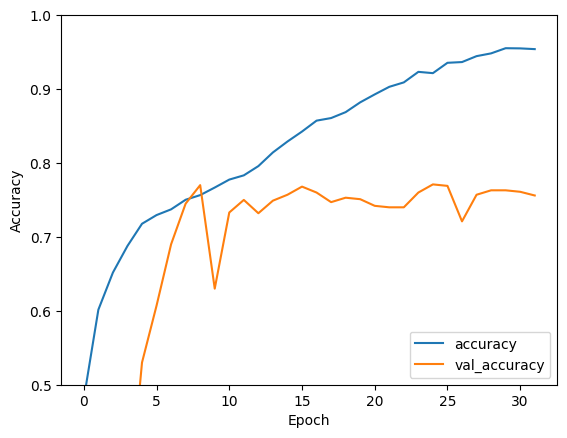

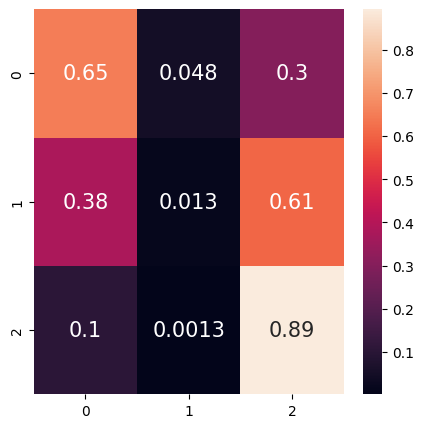

In [ ]:
#############
# ACTUALLY DOING EVERYTHING

fragmentChannels = 64;

datasetTrainX, datasetTestX, datasetTrainY, datasetTestY, resolution = doData( \
    "./data/Hotel_Reviews.csv", \
    _fragmentChannels = fragmentChannels, \
    _padVectors = True \
);

print(
    "  >>> training data:",
    "\n    # textures (number of reviews):",
    "\n    " + str(len(datasetTrainX)),
    "\n    # resolution (dimensions of texture in fragments):",
    "\n    " + str(len(datasetTrainX[0])),
    "\n    # colour space dimensionality (channels per fragment):",
    "\n    " + str(len(datasetTrainX[0][0]))
);

model, history = makeModel( datasetTrainX, datasetTestX, datasetTrainY, datasetTestY, resolution, fragmentChannels );

confusionMatrix = evaluateModel( model, datasetTestX, datasetTestY );
plotAll( history, confusionMatrix );


# Task 2 Convolution Neural Network

#### a) 

##### Sources used to guide this task: "https://medium.com/x8-the-ai-community/solving-class-imbalance-problem-in-cnn-9c7a5231c478" and "https://medium.com/@seelcs12/cnns-for-imbalanced-image-classification-with-tensorflow-7284a8c4a2e4"

We start by loading the dataset from CIFAR-10 with all 60000 images. We split them into our training and test data. In addition we also normalize the images as it will be easier for our model to learn from.

In [77]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

Our task at hand was to create a binary CNN with the CIFAR-10 dataset. After going through most of the data we found out that changing the labels into a binary relation would help greatly into making this CNN fit for our task. In our case we chose that this model should identify frogs, which in the dataset was the label ``[6]``. So we start by going through the dataset to set our new labels for our data.

In [78]:
num_class = 6

for n in range(len(y_train)):
    if y_train[n] == [num_class]:
        y_train[n] = [1]
    else:
        y_train[n] = [0]

for n in range(len(y_test)):
    if y_test[n] == [num_class]:
        y_test[n] = [1]
    else:
        y_test[n] = [0]

#### Undersampling the data

After some careful feedback and consideration we found that the dataset would be quite imbalanced. As we only have 5000 training images of frogs and 45000 non frog pictures. To make the model understand the frog we decided to undersample our dataset so we have even frog and non frog pictures. We tried to this with our test data as well, but thought that more pictures would mean better results for our model, we come back to this in our evaluation. 

In [86]:
x_tr_frog = []
y_tr_frog = []
for n in range(len(y_train)):
    if y_train[n] == [1]:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([1])

for n in range(len(y_train)):
    if len(x_tr_frog) < 10000:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([0])

x_tr_frog = np.array(x_tr_frog)
y_tr_frog = np.array(y_tr_frog)

#### The model.

Creating the function `make_model`, so we can create two different models with the same model building blocks. Start with 32 units of ``Conv2D`` with the input size set to our pictures size. Went with the solid `relu` activation. Than a `BatchNormalization` which speeds up our CNN to find an optimal solution. Then a `MaxPooling2D` which reduces the shape of our pictures and extract valueable features of the picture. This is our base layer which we use two times in our model before we add the last `Conv2D` and `BatchNormalization`. In the last 'layer' we start adding our `Dense` units to actually train the model. We use the same activation throughout the model, in addition we add a `kernel_regularizer` which helps the model's weights. We also add `Dropout's` units to help with overfitting. Our last `Dense` unit will serve as our output and therefore have the activation `sigmoid` to get the models prediction between 0 and 1. After quite some testing and checking our over/under-fitting graphs and saw quite many spikes we decided to increase our batch size to 128 to better comlpy with the big test set.

In [93]:
def make_model(metric, x_train, y_train, x_val, y_val):
    with tf.device('/GPU:0'):
        model = models.Sequential()
        model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(128, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(256, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())

        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(1, activation='sigmoid'))

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[metric])

        early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

        history = model.fit(
            x_train,
            y_train,
            batch_size = 128,
            epochs = 50,
            validation_data = (x_val, y_val),
            callbacks = [early_stopping]
        )
        return model, history

#### Training the model.

Question to TA: Would it be optimal to compare two different models and explain why the one model is better than the other, or is it better present one model and explain what makes it good.

After some careful consideration and testing with different metrics. We decided to compare two of our models, one with the metric `accuracy`, like our previous models, and one with the `F1-score` metric. The two models use the exact same training set and test set. Both also have an early stopping when our `val_loss` does not improve over five epochs. After training both models we start comparing them in our evaluation. We chose to go for a medium threshold on our `F1Score` since this was quite better than the low and high thresholds.

In [94]:
acc_model, acc_history = make_model('accuracy', x_tr_frog, y_tr_frog, x_test, y_test)

f1_model, f1_history = make_model(F1Score(threshold=0.5, average='micro'), x_tr_frog, y_tr_frog, x_test, y_test)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.7052 - loss: 2.5063 - val_accuracy: 0.1000 - val_loss: 2.1328
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8195 - loss: 1.5388 - val_accuracy: 0.8640 - val_loss: 1.2203
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8342 - loss: 1.0348 - val_accuracy: 0.8975 - val_loss: 0.8930
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8597 - loss: 0.7198 - val_accuracy: 0.8335 - val_loss: 0.7069
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8698 - loss: 0.5779 - val_accuracy: 0.7540 - val_loss: 0.6572
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8815 - loss: 0.4755 - val_accuracy: 0.9014 - val_loss: 0.4007
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8870 - loss: 0.4398 - val_accuracy: 0.9190 - val_loss: 0.3389
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8983 - loss: 0.3948 - val_accuracy: 0.7289 - v

#### Evalution graphs

Creating `confusion_matrix` for each model to compare what makes them different. Uses `seaborn` to show the matrices.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


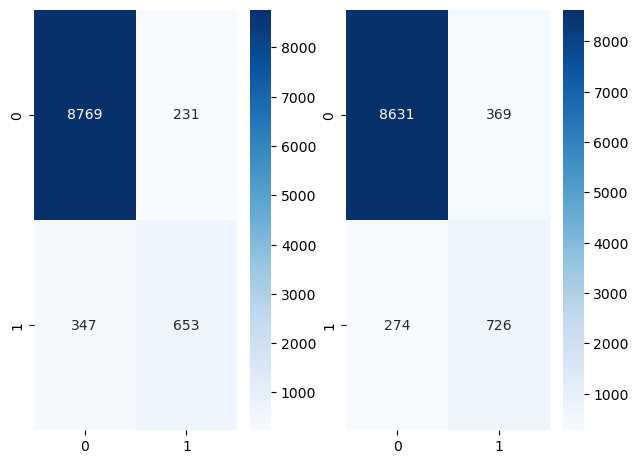

In [100]:
def made_predictions(predictions):
    array = []
    for pred in predictions:
        if max(pred) > 0.7:
            array.append([1])
        else:
            array.append([0])
    return np.array(array)

y_pred_acc = acc_model.predict(x_test)
y_pred_acc = made_predictions(y_pred_acc)
best_cf = confusion_matrix(y_test, y_pred_acc)

y_pred_f1 = f1_model.predict(x_test)
y_pred_f1 = made_predictions(y_pred_f1)
worse_cf = confusion_matrix(y_test, y_pred_f1)

fig, ax = plt.subplots(1,2)
fig.tight_layout()
sns.heatmap(best_cf, annot=True, cmap='Blues', fmt='d', ax=ax[0])
sns.heatmap(worse_cf, annot=True, cmap='Blues', fmt='d', ax=ax[1])
fig.savefig('./matplotlib_data/conf_mat_CNN')
fig.show()

#### Checking underfitting and overfitting

As we mentioned the huge imbalance in our dataset, it is important to chech if our models actually overfit or underfit in our models. We create these two graphs using `seaborn` to check.

313/313 - 1s - 4ms/step - accuracy: 0.9365 - loss: 0.2658


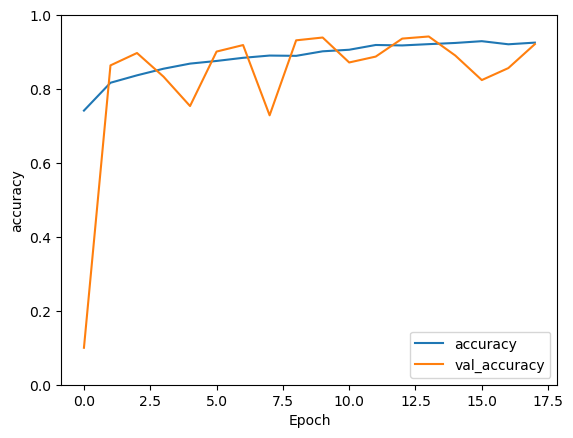

In [101]:
plt.plot(acc_history.history['accuracy'], label='accuracy')
plt.plot(acc_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')
plt.savefig('./matplotlib_data/over_acc_CNN')

test_loss, test_acc = acc_model.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - f1_score: 0.6749 - loss: 0.2997


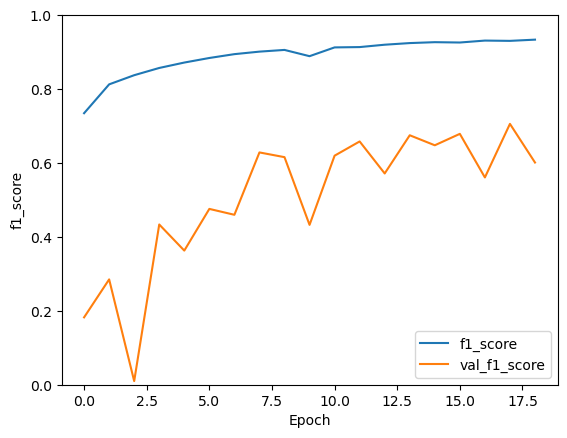

In [102]:
plt.plot(f1_history.history['f1_score'], label='f1_score')
plt.plot(f1_history.history['val_f1_score'], label = 'val_f1_score')
plt.xlabel('Epoch')
plt.ylabel('f1_score')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')
plt.savefig('./matplotlib_data/over_f1_CNN')

test_loss, test_acc = f1_model.evaluate(x_test, y_test, verbose=2)

#### Task 2b)

Found these pictures from Google: 

* Image 1: https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.wcs.org%2Fget-involved%2Fupdates%2Ffascinating-frogs&psig=AOvVaw28_HGqOe7S2sxjPK3bsI5N&ust=1744278715616000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCKDFld_WyowDFQAAAAAdAAAAABAE

* Image 2: https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.twinkl.pt%2Fteaching-wiki%2Ffrog&psig=AOvVaw0bdQuBJB9qO9gkRwCWvou-&ust=1744633397275000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCPCGuIGA1YwDFQAAAAAdAAAAABAE

* Image 3: https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.nytimes.com%2Fwirecutter%2Freviews%2Fnew-dog-checklist%2F&psig=AOvVaw2ZPUsP1HTJbZhOYM2tqHPx&ust=1744633423068000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCND_iI6A1YwDFQAAAAAdAAAAABAE

* Image 4: https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.goodwood.com%2Fgrr%2Ff1%2Fthe-nine-best-f1-cars-of-all-time%2F&psig=AOvVaw0_NSf08TH2_7ChAB8GfZhd&ust=1744633440992000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCNi76pWA1YwDFQAAAAAdAAAAABAE

Used Tensorflows own `load_img` to convert the pictures to the right size for our models. Then we show how the pictures will look for our models, to see if they have any meaningful similarities that could make the model make a wrong prediction. 

##### Conversion.

After that we convert the images into their array form so we can actually use them in our model. Not much meaningful parameters are used as we just convert and normalize the array as we did earlier. 

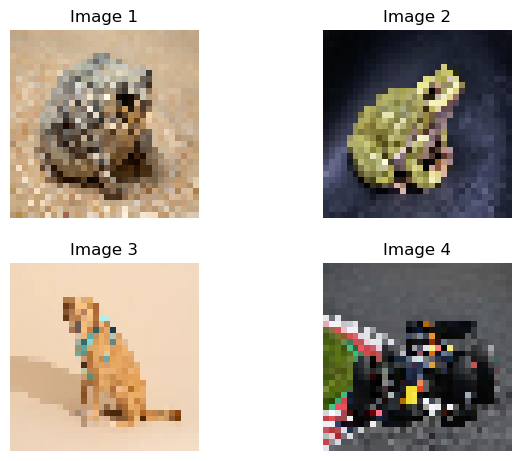

In [98]:
# Showing the pictures we are using to test the models
images = []

img_1 = tf.keras.utils.load_img('./media/frog_6.jpg', target_size=(32, 32))
img_2 = tf.keras.utils.load_img('./media/frog_4.jpg', target_size=(32, 32))
img_3 = tf.keras.utils.load_img('./media/dog_2.jpg', target_size=(32, 32))
img_4 = tf.keras.utils.load_img('./media/f1.jpg', target_size=(32, 32))

images.append(img_1)
images.append(img_2)
images.append(img_3)
images.append(img_4)

fig, ax = plt.subplots(2, 2)
fig.tight_layout()
ax = ax.flatten()

images_for_model = []
num = 1

for img, ax in zip(images, ax):
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.array(img_array) / 255.0 # Normalize
    images_for_model.append(img_array)
    ax.imshow(img_array)
    ax.set_title(f'Image {num}')
    ax.axis('off')
    num += 1

plt.show()

#### Prediction.

Before we actually predict our images we first have to add a batch so that our model acctually can use our arrays. When we get our prediction back we make it into a percentage so it is more readable. Here we also added a threshhold to decide if we think our models actually predicted right or not. We found that if the model was 70% sure it was a frog it mostly was right. We can see all the predictions below.

In [99]:
# Actual predictions
print("Hi! I'm Accuracy and I think that: ")
for num in range(len(images_for_model)):
    img = images_for_model[num]
    img = tf.expand_dims(img, 0) # Create a batch
    pred = acc_model.predict(img)
    pred = pred[0][0] * 100
    print(f"    Image {num + 1} is: ", end="")
    if pred > 70:
        print(f'{pred:.2f}% a frog.')
    else:
        print(f'{100 - pred:.2f}% not a frog')

print("\n-----------CHANGING MODEL-----------\n")

print("Hi! I'm F1 and I actually think that: ")
for num in range(len(images_for_model)):
    img = images_for_model[num]
    img = tf.expand_dims(img, 0) # Create a batch
    pred = f1_model.predict(img)
    pred = pred[0][0] * 100
    print(f"    Image {num + 1} is: ", end="")
    if pred > 70:
        print(f'{pred:.2f}% a frog.')
    else:
        print(f'{100 - pred:.2f}% not a frog')

Hi! I'm Accuracy and I think that: 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
    Image 1 is: 87.35% a frog.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
    Image 2 is: 99.55% a frog.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
    Image 3 is: 99.43% not a frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
    Image 4 is: 74.11% not a frog

-----------CHANGING MODEL-----------

Hi! I'm F1 and I actually think that: 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
    Image 1 is: 31.33% not a frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
    Image 2 is: 99.96% a frog.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
    Image 3 is: 86.78% not a frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
    Image 4 is: 67.61% not a frog


### Conclusion of task 1.

...

### Conclusion of task 2.

To summarize quitle short, we have now created two convolutional neural network as a binary classifier of one category. And tested them with pictures from the internet to see if it actually could predict a frog or not. When doing this task is starts quite simple by just building a neural network like we did in task 1. But when actually trying to optimize and find the right parameters, metric, training or test size would be quite tidy to do. When just comparing the two models there is quite significant changes in both. Like when we see at their `confusion matrices`.

![Conf_matrices](./matplotlib_data/conf_mat_CNN.png)